# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

## Problem Statement
In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

### Objective
This project's main goal is to run an A/B test to examine the relationship between the fare amounts and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

#### Research Question
Is there a relationship between total fare amount and payment type and can we nudge customers toward payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

In [1]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as st 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Dataset From the 'data' folder 
df = pd.read_csv('C:\\Users\\Kartik Bhaskar\\Desktop\\statistics project\\data\\yellow_tripdata_2020-01.csv')

In [3]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [4]:
# Exploratory Data Analysis

In [5]:
df.shape

(6405008, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), object(3)
memory usage: 879.6+ MB


In [7]:
# Converting data types

In [8]:
# object to date time 
date_col = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
df[date_col] = df[date_col].apply(pd.to_datetime)

In [9]:
# creatng new feature duration using the existing fields 
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60

In [10]:
df.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
duration                        float64
dtype: object

There are so many columns in the dataset, but as per our problem statement, we only require some fields from the original data. Rest columns are nothing but the unwanted columns for this study. So we will simply remove those columns.

As the problem statement is revolving around the payment type, fare amount, and any other factor influencing the fare amount, we will filter the data to have only passenger count, trip distance, payment type, fare amount and duration of the trip.

In [11]:
# filtered data with relevant columns essential for the analysis
df = df[['payment_type', 'fare_amount', 'passenger_count', 'trip_distance', 'duration']]
df

,payment_type,fare_amount,passenger_count,trip_distance,duration
0,1.0,6.00,1.0,1.20,4.800000
1,1.0,7.00,1.0,1.20,7.416667
2,1.0,6.00,1.0,0.60,6.183333
3,1.0,5.50,1.0,0.80,4.850000
4,2.0,3.50,1.0,0.00,2.300000
...,...,...,...,...,...
6405003,NaN,17.59,NaN,3.24,31.000000
6405004,NaN,46.67,NaN,22.13,76.000000
6405005,NaN,48.85,NaN,10.51,27.833333
6405006,NaN,27.17,NaN,5.49,22.650000


In [12]:
# data cleaining 

In [13]:
# check for missing values 
df.isnull().sum()

payment_type       65441
fare_amount            0
passenger_count    65441
trip_distance          0
duration               0
dtype: int64

In [14]:
# percentage of the missing records to the total records of the data 
missing_pct = 65441 / len(df) * 100
print(f"Missing data = {missing_pct:.2f}%")

Missing data = 1.02%


In [15]:
# as the data has only 1% of data missing, we can simply drop the records with missing values.
df.dropna(inplace=True)

In [16]:
# check for the duplicate rows
df[df.duplicated()]

,payment_type,fare_amount,passenger_count,trip_distance,duration
2056,2.0,7.0,1.0,0.00,0.000000
2441,1.0,52.0,1.0,0.00,0.200000
2446,1.0,9.5,2.0,1.70,13.066667
2465,1.0,4.0,1.0,0.40,3.083333
3344,1.0,6.0,1.0,1.20,5.350000
...,...,...,...,...,...
6339558,2.0,8.0,1.0,1.63,8.800000
6339559,1.0,8.5,1.0,1.81,8.016667
6339560,2.0,6.5,1.0,0.98,6.900000
6339562,1.0,11.0,1.0,2.10,14.233333


In [17]:
# removing duplicate rows as they will not contribute in analysis
df.drop_duplicates(inplace=True)

In [18]:
# # changing the passenger count and payment type data type to integer as they are present in float
int_col = ['payment_type', 'passenger_count']
df[int_col] = df[int_col].astype(int)

In [19]:
# passenger count distribution
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

In [20]:
# payment type distribution
df['payment_type'].value_counts(normalize=True)

payment_type
1    6.782670e-01
2    3.075731e-01
3    8.721480e-03
4    5.438084e-03
5    3.324622e-07
Name: proportion, dtype: float64

We will focus solely on payment types **'card'** and **'cash'**, denoted by **1** and **2** in the dataset. To ensure our analysis centers on these payment methods, we'll filter the data accordingly, excluding all other types.

Moreover, examining the distribution of passenger counts reveals that trips with more than **5 passengers** are rare. Additionally, trips with **0 passengers** are impossible, as we expect at least one passenger to pay the fare amount. Therefore, we will filter the passenger count to include only values ranging from **1 to 5**.

In [21]:
# filtering for payment type 1 and 2
df = df[df['payment_type']<3]

# filtering for passenger count from 1 to 5
df = df[(df['passenger_count']>0)&(df['passenger_count']<6)]

In [22]:
df

,payment_type,fare_amount,passenger_count,trip_distance,duration
0,1,6.0,1,1.20,4.800000
1,1,7.0,1,1.20,7.416667
2,1,6.0,1,0.60,6.183333
3,1,5.5,1,0.80,4.850000
4,2,3.5,1,0.00,2.300000
...,...,...,...,...,...
6339555,1,10.0,3,2.09,14.800000
6339561,1,17.5,1,4.11,21.500000
6339563,1,13.0,1,2.13,19.000000
6339564,1,12.5,1,2.55,16.283333


In [23]:
# replacing the payment type encoded value 1 and 2 to Card and Cash
df['payment_type'].replace([1,2], ['card', 'cash'], inplace=True)

In [24]:
# descriptive statistics for data
df.describe()

,fare_amount,passenger_count,trip_distance,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.780567e+01,1.733386e+00,4.536729e+00,2.415478e+01
std,1.506997e+01,1.176652e+00,4.895890e+00,9.260031e+01
min,-5.000000e+02,1.000000e+00,-2.218000e+01,-2.770367e+03
25%,9.000000e+00,1.000000e+00,1.500000e+00,9.883333e+00
50%,1.300000e+01,1.000000e+00,2.730000e+00,1.573333e+01
75%,2.100000e+01,2.000000e+00,5.470000e+00,2.336667e+01
max,4.265000e+03,5.000000e+00,2.628800e+02,8.525117e+03


Upon reviewing the provided statistics, it's evident that the minimum values for **trip distance**, **fare amount**, and **duration** are negative, which is unrealistic and invalid for further analysis. Consequently, we will eliminate these negative values from the dataset.

In [25]:
# filtering the records for only positive values
df = df[df['duration']>0]
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]

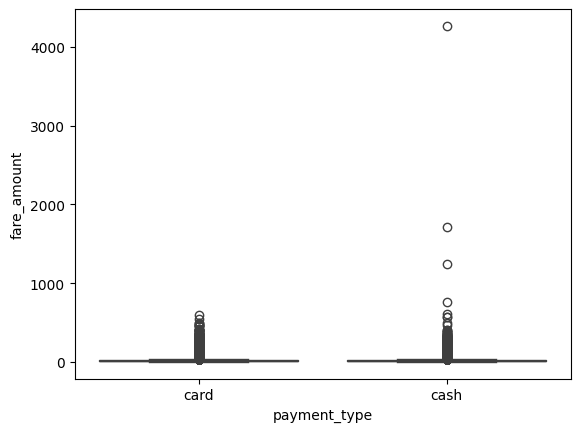

In [26]:
# check for the outliers
sns.boxplot(data=df, y="fare_amount", x="payment_type")
plt.show()

In [27]:
# removing outliers using interquartile range for the numerical variables
for col in ['duration', 'fare_amount', 'trip_distance']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR
    df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

We're interested in exploring the relationship between payment type and passenger behavior concerning trip distance and fare amount. Are there variations in the distribution of payment types concerning different fare amounts or trip distances?

To investigate this, we'll plot histograms to visualize the distribution of passenger counts paying with either card or cash. This will also provide stakeholders with insight into fare amount ranges associated with different payment methods.

In [28]:
# Analysis & visualization 

In [29]:
# Does customer prefer cash or card on the bases of fare amount and trip distance?

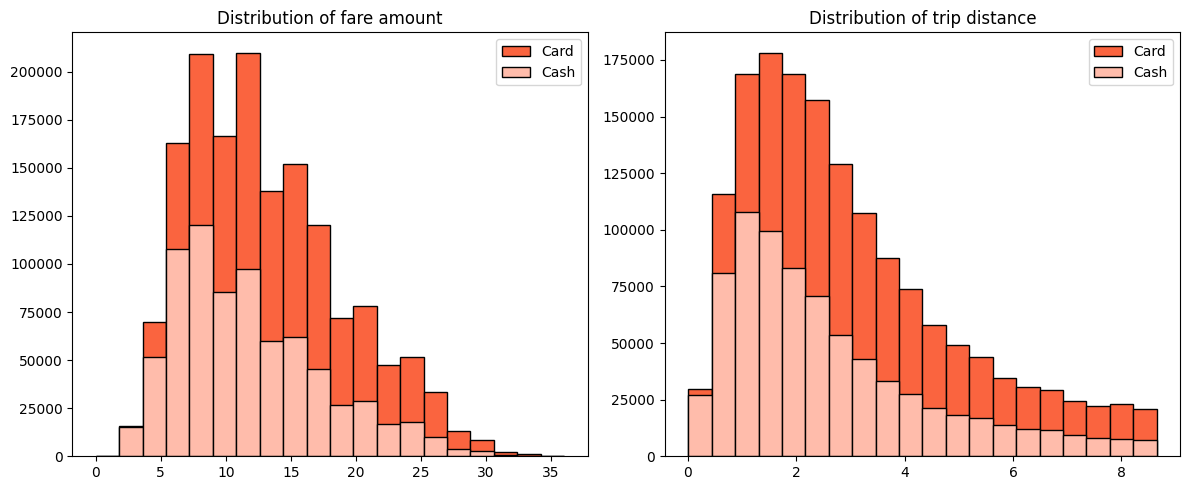

In [30]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df[df['payment_type']=='card']['fare_amount'], histtype='barstacked', bins=20, edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type']=='cash']['fare_amount'], histtype='barstacked', bins=20, edgecolor='k', color='#FFBCAB', label='Cash')
plt.legend()
plt.title("Distribution of fare amount")

plt.subplot(1,2,2)
plt.hist(df[df['payment_type']=='card']['trip_distance'], histtype='barstacked', bins=20, edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type']=='cash']['trip_distance'], histtype='barstacked', bins=20, edgecolor='k', color='#FFBCAB', label='Cash')
plt.legend()
plt.title("Distribution of trip distance")
plt.tight_layout()
plt.savefig("payment_type_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
df.groupby('payment_type').agg({'fare_amount':['mean', 'std'], 'trip_distance':['mean', 'std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
card           13.150848  5.886713      2.975965  1.950232
cash           11.780946  5.641666      2.588335  1.876433

Now, in order to examine the passenger's preference regarding their choice of payment method, we will assess the proportion of the two payment types. To provide a visual representation, we have opted to utilize a pie chart. This graphical depiction will offer a clear and intuitive understanding of the distribution between the two payment methods chosen by passengers.

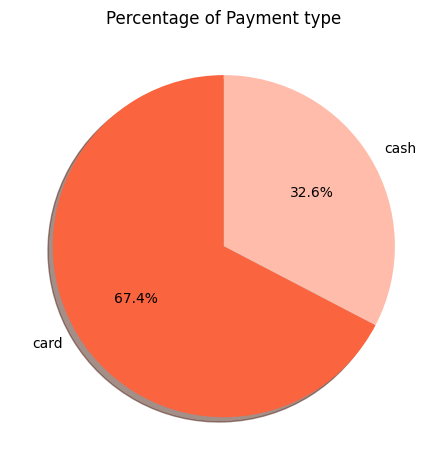

In [33]:
plt.pie(df['payment_type'].value_counts(normalize=True), labels=df['payment_type'].value_counts().index,
       startangle=90, shadow=True, autopct= '%1.1f%%', colors=['#FA643F', '#FFBCAB'])
plt.title("Percentage of Payment type")
plt.tight_layout()
plt.savefig("percentage_of_payment_type.png", dpi=300, bbox_inches="tight")
plt.show()

Subsequently, we aim to conduct an analysis of the payment types in relation to the passenger count. Our objective is to investigate if there are any changes in preference contingent upon the number of passengers traveling in the cab.

To facilitate this examination, we have employed a visualization technique known as a stacked bar plot. This method is particularly advantageous for comparing the percentage distribution of each passenger count based on the payment method selected. Through this graphical representation, we can gain insights into potential variations in payment preferences across different passenger counts.

In [34]:
# does customers prefer the card or cash on the bases of count of passensger?

In [35]:
df.columns

Index(['payment_type', 'fare_amount', 'passenger_count', 'trip_distance',
       'duration'],
      dtype='object')

In [36]:
# calculating the total passenger count distribution based on the different payment type
passenger_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()

# creaming the passenger_count to count to reset the index
passenger_count.rename(columns={'passenger_count':'count'}, inplace=True)
passenger_count.reset_index(inplace=True)

# calculating the percentage of the each passenger count
passenger_count['pct'] = round((passenger_count['count']/passenger_count['count'].sum())*100,2)
passenger_count

,payment_type,passenger_count,count,pct
0,card,1,912889,39.62
1,card,2,328523,14.26
2,card,3,122610,5.32
3,card,4,63727,2.77
4,card,5,124134,5.39
5,cash,1,461371,20.02
6,cash,2,155767,6.76
7,cash,3,54603,2.37
8,cash,4,32797,1.42
9,cash,5,47627,2.07


In [37]:
df_tran = df.copy()

In [38]:
# creating a new memory dataframe to store the distribution of each payment type (useful for the visualization)
df_tran = pd.DataFrame(columns=['payment_type', 1,2,3,4,5])
df_tran['payment_type'] = ['Card', 'Cash']
df_tran.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df_tran.iloc[1,1:] = passenger_count.iloc[5:,-1]
df_tran

,payment_type,1,2,3,4,5
0,Card,39.62,14.26,5.32,2.77,5.39
1,Cash,20.02,6.76,2.37,1.42,2.07


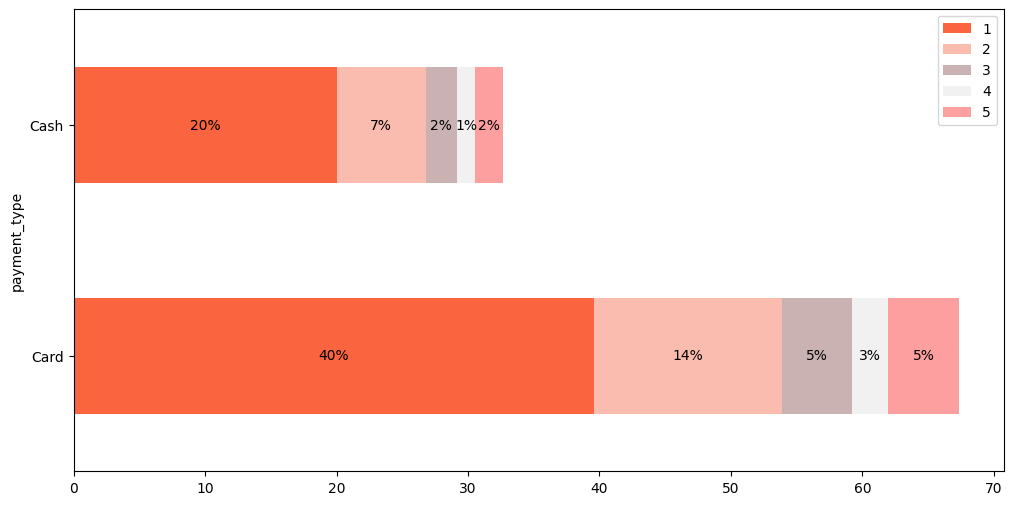

In [39]:
fig, ax = plt.subplots(figsize=(12,6))
df_tran.plot(x = 'payment_type', kind='barh', stacked=True, ax=ax, color=['#FA643F', '#FABCAF', '#CBB2B2','#F1F1F1','#FD9F9F'])

# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center')

plt.savefig("percentage_of_share_in_cash_and_card.png", dpi=300, bbox_inches="tight")

In [40]:
# hypothesis testing

In order to select the most suitable test for our scenario, our initial step involves evaluating whether the distribution of fare amounts adheres to a normal distribution. While the histogram depicted above suggests otherwise, we will further confirm this by generating a QQ plot.

Quantile-quantile (QQ) plots can be used to assess whether the fare amount distributions for each payment type are approximately normally distributed. If the data points closely align with the diagonal line in the plot, it suggests that the data follows a normal distribution.

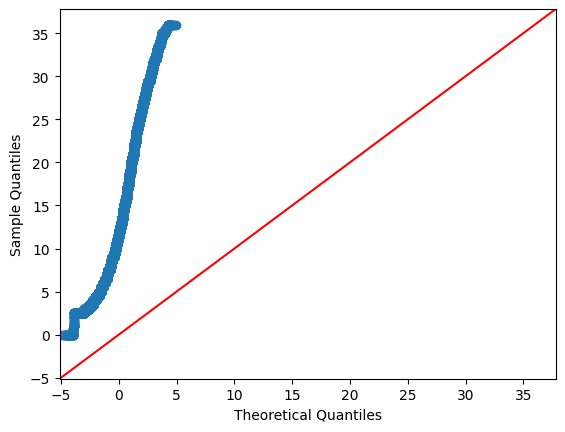

In [41]:
import statsmodels.api as sm 
sm.qqplot(df['fare_amount'], line='45')
plt.show()

The data values clearly do not follow the red 45-degree line, which is an indication that they do not follow a normal distribution. So, z distribution will not be good for this. That's why we will use T test.

Given that the T-test can be applied to both small and large samples and does not require the population standard deviation, it is a more universally applicable approach for hypothesis testing in many practical research scenarios, including analyses of taxi trip data.

In the analysis of NYC Yellow Taxi Trip Records, where you're likely dealing with an unknown population standard deviation and potentially large datasets, the T-test offers a more appropriate and flexible method for comparing means between two groups (e.g., fare amounts by payment type). It provides a reliable way to infer about the population, accommodating the uncertainty that comes with estimating population parameters from sample data.

Null hypothesis: There is no difference in average fare between customers who use credit cards and customers who use cash.

Alternative hypothesis: There is a difference in average fare between customers who use credit cards and customers who use cash.

In [42]:
# sample 1
card_sample = df[df['payment_type'] == 'card']['fare_amount']

# sample 2
cash_sample = df[df['payment_type'] == 'cash']['fare_amount']

In [43]:
# performing t test on both the different sample
t_stats, p_value = st.ttest_ind(a=card_sample, b=cash_sample, equal_var=False)
print('T statistics', t_stats, 'p-value', p_value)

T statistics 170.38051479105548 p-value 0.0


Since the p-value is significantly smaller than the significance level of 5%, we reject the null hypothesis.

You conclude that there is a statistically significant difference in the average fare amount between customers who use credit cards and customers who use cash.

The key business insight is that encouraging customers to pay with credit cards can generate more revenue for taxi cab drivers.